In [1]:
import pandas as pd
import numpy as np

In [2]:
import sys
print(sys.executable)

C:\Users\HP\AppData\Local\Programs\Python\Python314\python.exe


In [3]:
df = pd.read_csv("../data/netflix_titles.csv")

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [6]:
df.shape

(8807, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [8]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [12]:
# Count missing values in each column
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [13]:
# Calculate percentage of missing values per column
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

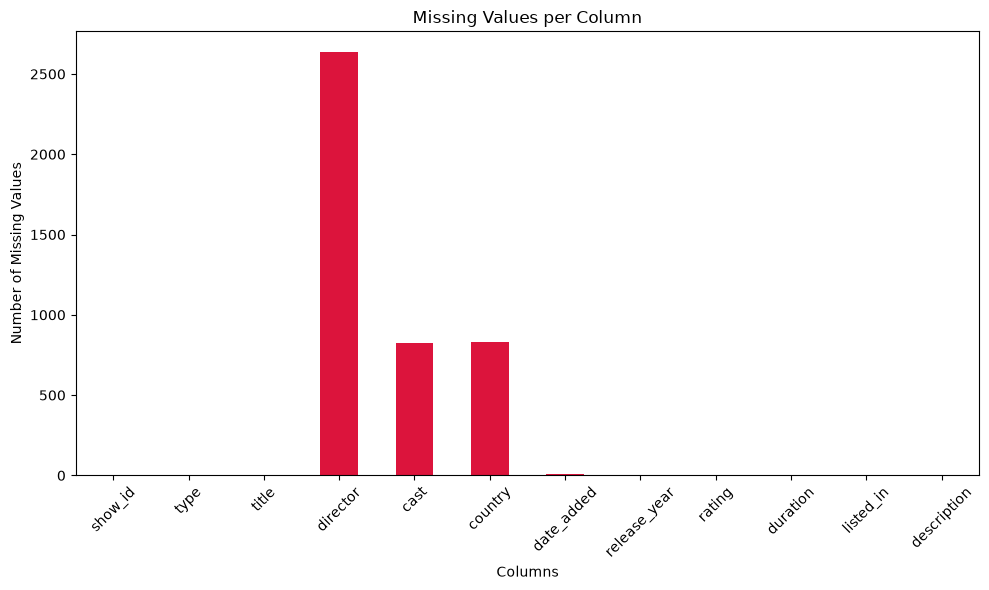

In [14]:
import matplotlib.pyplot as plt

# Visualize missing values
plt.figure(figsize=(10,6))
df.isnull().sum().plot(kind='bar', color='crimson')
plt.title('Missing Values per Column')
plt.ylabel('Number of Missing Values')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Fill missing values in director, cast, and country with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [16]:
# Drop rows where date_added, rating, or duration is missing
df = df.dropna(subset=['date_added', 'rating', 'duration'])

In [17]:
# Confirm no missing values remain in the key columns
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [18]:
# Remove leading/trailing spaces from text columns
df['title'] = df['title'].str.strip()
df['director'] = df['director'].str.strip()
df['cast'] = df['cast'].str.strip()
df['country'] = df['country'].str.strip()

In [19]:
# Convert date_added column to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [20]:
# Create a new column extracting just the year from date_added
df['year_added'] = df['date_added'].dt.year

In [21]:
# Standardize text casing for consistency
df['type'] = df['type'].str.title()
df['country'] = df['country'].str.title()

In [22]:
# Save the cleaned dataset to the data folder
df.to_csv('../data/netflix_titles_cleaned.csv', index=False)


In [23]:
# Confirm no missing values remain
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      88
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      88
dtype: int64

In [24]:
# Confirm no duplicate rows
df.duplicated().sum()

np.int64(0)

In [25]:
# Confirm data types are correct
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
year_added             float64
dtype: object

In [26]:
# Confirm date_added is a proper datetime and year_added exists
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [27]:
# Convert year_added to a clean integer
df['year_added'] = df['year_added'].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')

In [ ]:
# Check how many rows have missing year_added
df['year_added'].isnull().sum()

In [ ]:
# Drop any remaining rows with missing year_added
df = df.dropna(subset=['year_added'])

# Now safely convert to integer
df['year_added'] = df['year_added'].astype(int)

In [ ]:
# Re-save the cleaned dataset with the year_added fix
df.to_csv('../data/netflix_titles_cleaned.csv', index=False)

In [ ]:
df['year_added'].dtype

In [ ]:
# Q1: Movies vs TV Shows
df['type'].value_counts()

In [28]:
df['type'].value_counts()

type
Movie      6126
Tv Show    2664
Name: count, dtype: int64

In [29]:
# Q2: Top 10 Countries by Content Count
df['country'].value_counts().head(10)

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [30]:
# Q3: Most Common Genres
df['listed_in'].value_counts().head(10)

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            219
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

In [31]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [32]:
df['year_added'].value_counts().sort_index()

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     415
2017.0    1161
2018.0    1624
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

In [33]:
# Extract numeric minutes from duration column (Movies only)
movies = df[df['type'] == 'Movie'].copy()
movies['duration_minutes'] = movies['duration'].str.replace(' min', '').astype(int)
movies['duration_minutes'].mean()

np.float64(99.58488410055502)

In [34]:
# Q7: Top 10 Directors
df['director'].value_counts().drop('Unknown').head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

In [35]:
# Q8: Top 10 Actors
from collections import Counter
cast_list = df[df['cast'] != 'Unknown']['cast'].str.split(', ')
all_actors = Counter([actor for sublist in cast_list for actor in sublist])
pd.Series(all_actors).sort_values(ascending=False).head(10)

Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Om Puri             30
Akshay Kumar        30
Yuki Kaji           29
Paresh Rawal        28
dtype: int64

In [36]:
# Q9: Movies vs TV Shows Added Per Year
df.groupby(['year_added', 'type']).size().unstack()

type,Movie,Tv Show
year_added,,
2008.0,1.0,1.0
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,13.0,NaN
2012.0,3.0,NaN
2013.0,6.0,4.0
2014.0,19.0,4.0
2015.0,56.0,17.0
2016.0,251.0,164.0


In [37]:
# Q10: Top 5 Longest Movies
movies.sort_values('duration_minutes', ascending=False)[['title', 'duration_minutes']].head(5)

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312
717,Headspace: Unwind Your Mind,273
2491,The School of Mischief,253
2487,No Longer kids,237
2484,Lock Your Girls In,233


In [38]:
# Q11: Top 5 Shortest Movies
movies.sort_values('duration_minutes', ascending=True)[['title', 'duration_minutes']].head(5)

,title,duration_minutes
3777,Silent,3
2713,Sol Levante,5
1484,Cops and Robbers,8
1557,Canvas,9
3535,American Factory: A Conversation with the Obamas,10


In [39]:
# Q12: Top 5 Newest Releases
df.sort_values('release_year', ascending=False)[['title', 'release_year']].head(5)

,title,release_year
1,Blood & Water,2021
8437,The Netflix Afterparty,2021
31,Chicago Party Aunt,2021
30,Ankahi Kahaniya,2021
25,Love on the Spectrum,2021


In [40]:
# Q13: Top 5 Oldest Releases
df.sort_values('release_year', ascending=True)[['title', 'release_year']].head(5)

,title,release_year
4250,Pioneers: First Women Filmmakers*,1925
7790,Prelude to War,1942
8205,The Battle of Midway,1942
8739,Why We Fight: The Battle of Russia,1943
8763,WWII: Report from the Aleutians,1943


In [41]:
# Q14: Top 5 Production Countries
df['country'].value_counts().head(5)

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
Name: count, dtype: int64

In [42]:
United States    2809
India             972
Unknown           829
United Kingdom    418
Japan             243

SyntaxError: invalid syntax (712284386.py, line 1)